In [34]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy import special
from scipy import optimize
from tqdm import tqdm
from math import floor
import statsmodels.api as sm

In [2]:
def gen():
    return int(np.random.random() * 10**6)

# 1. Генерация данных

In [27]:
def generator_uniform(n):
    return np.random.uniform(-0.05 * np.sqrt(3), 0.05 * np.sqrt(3), n)

def generator_normal(n):
    return np.random.normal(0, 0.05**2, n)

def generator_laplace(n):
    return stats.laplace.rvs(loc=0, scale=np.sqrt(0.05**2 / 2), size=n)

In [28]:
x_arange = np.arange(0.1, 3.1, 0.1)

In [26]:
def f(x):
    return x / (x + 1)

In [35]:
def get_sample(noise_generator):
    return np.array([
        [x, f(x) + noise] for x, noise in zip(x_arange, noise_generator(30))
    ])

In [116]:
sample = get_sample(generator_normal)
sample

array([[0.1       , 0.0932887 ],
       [0.2       , 0.16747409],
       [0.3       , 0.22958028],
       [0.4       , 0.28959094],
       [0.5       , 0.33412775],
       [0.6       , 0.37737974],
       [0.7       , 0.41293499],
       [0.8       , 0.44449376],
       [0.9       , 0.47346084],
       [1.        , 0.49727203],
       [1.1       , 0.52455372],
       [1.2       , 0.54481623],
       [1.3       , 0.56417417],
       [1.4       , 0.5831961 ],
       [1.5       , 0.59915556],
       [1.6       , 0.61828889],
       [1.7       , 0.62795217],
       [1.8       , 0.64510587],
       [1.9       , 0.65660862],
       [2.        , 0.66894807],
       [2.1       , 0.67511921],
       [2.2       , 0.68707416],
       [2.3       , 0.69348941],
       [2.4       , 0.70391681],
       [2.5       , 0.71544344],
       [2.6       , 0.72251254],
       [2.7       , 0.72863612],
       [2.8       , 0.73593806],
       [2.9       , 0.74382599],
       [3.        , 0.74801293]])

# 2. Построение регрессии

In [84]:
def get_parameteres_ols(sample):
    def loss_function_ols(a):
        a_0, a_1, a_2 = a.tolist()
        return np.linalg.norm((np.expand_dims((sample[:, 0] * a_1 + a_0 * np.ones(30)) / (sample[:, 0] + a_2 * np.ones(30)), axis=1)) - np.expand_dims(sample[:, 1], axis=1), ord=2)

    return optimize.minimize(loss_function_ols, (0.0, 1.0, 1.0), tol=1e-6).x.tolist()


In [110]:
a_estimated_uniform_ols = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_uniform)
    a_estimated_uniform_ols.append(get_parameteres_ols(sample))

a_estimated_uniform_ols = np.array(a_estimated_uniform_ols)

100%|██████████| 1000/1000 [00:11<00:00, 84.21it/s]


In [111]:
a_estimated_normal_ols = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_normal)
    a_estimated_normal_ols.append(get_parameteres_ols(sample))

a_estimated_normal_ols = np.array(a_estimated_normal_ols)

100%|██████████| 1000/1000 [00:17<00:00, 56.22it/s]


In [112]:
a_estimated_laplace_ols = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_laplace)
    a_estimated_laplace_ols.append(get_parameteres_ols(sample))

a_estimated_laplace_ols = np.array(a_estimated_laplace_ols)

100%|██████████| 1000/1000 [00:12<00:00, 81.35it/s]


In [109]:
def get_parameteres_lar(sample):
    def loss_function_lar(a):
        a_0, a_1, a_2 = a.tolist()
        return np.linalg.norm((np.expand_dims((sample[:, 0] * a_1 + a_0 * np.ones(30)) / (sample[:, 0] + a_2 * np.ones(30)), axis=1)) - np.expand_dims(sample[:, 1], axis=1), ord=1)

    return optimize.minimize(loss_function_lar, (0.0, 1.0, 1.0), tol=1e-6).x.tolist()

In [113]:
a_estimated_uniform_lar = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_uniform)
    a_estimated_uniform_lar.append(get_parameteres_lar(sample))

a_estimated_uniform_lar = np.array(a_estimated_uniform_lar)

100%|██████████| 1000/1000 [00:46<00:00, 21.46it/s]


In [114]:
a_estimated_normal_lar = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_normal)
    a_estimated_normal_lar.append(get_parameteres_lar(sample))

a_estimated_normal_lar = np.array(a_estimated_normal_lar)

100%|██████████| 1000/1000 [00:40<00:00, 24.96it/s]


In [115]:
a_estimated_laplace_lar = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_laplace)
    a_estimated_laplace_lar.append(get_parameteres_lar(sample))

a_estimated_laplace_lar = np.array(a_estimated_laplace_lar)

100%|██████████| 1000/1000 [00:41<00:00, 24.22it/s]


In [125]:
def get_parameteres_minimax(sample):
    def loss_function_lar(a):
        a_0, a_1, a_2 = a.tolist()
        return np.max((np.expand_dims((sample[:, 0] * a_1 + a_0 * np.ones(30)) / (sample[:, 0] + a_2 * np.ones(30)), axis=1)) - np.expand_dims(sample[:, 1], axis=1))

    return optimize.minimize(loss_function_lar, (0.0, 1.0, 1.0), tol=1e-6).x.tolist()

In [124]:
np.max(np.expand_dims(np.array([1, 2, 3]), axis=0))

np.int64(3)

In [126]:
a_estimated_uniform_minimax = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_uniform)
    a_estimated_uniform_minimax.append(get_parameteres_minimax(sample))

a_estimated_uniform_minimax = np.array(a_estimated_uniform_minimax)

100%|██████████| 1000/1000 [00:35<00:00, 27.79it/s]


In [127]:
a_estimated_normal_minimax = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_normal)
    a_estimated_normal_minimax.append(get_parameteres_minimax(sample))

a_estimated_normal_minimax = np.array(a_estimated_normal_minimax)

100%|██████████| 1000/1000 [00:37<00:00, 26.73it/s]


In [128]:
a_estimated_laplace_minimax = []
for _ in tqdm(range(10**3)):
    sample = get_sample(generator_laplace)
    a_estimated_laplace_minimax.append(get_parameteres_minimax(sample))

a_estimated_laplace_minimax = np.array(a_estimated_laplace_minimax)

100%|██████████| 1000/1000 [00:38<00:00, 25.73it/s]


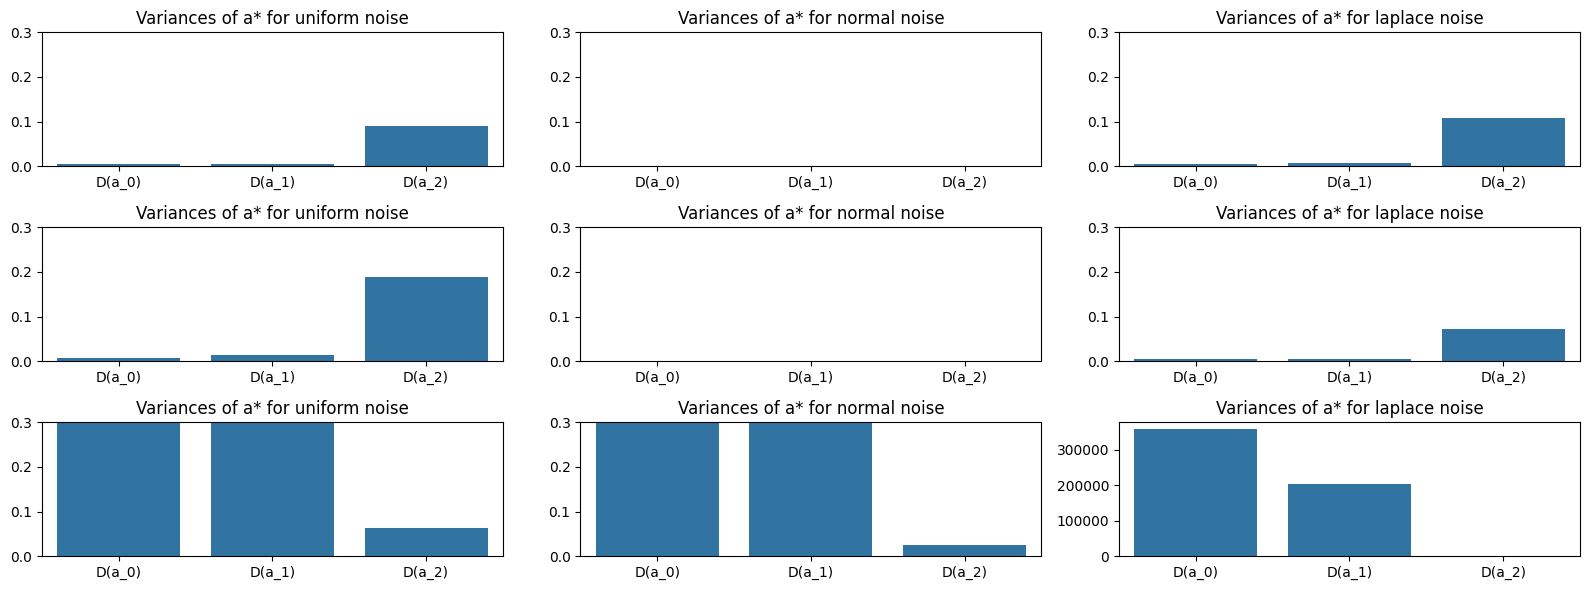

In [134]:
fig, axes = plt.subplots(3, 3, figsize=(16, 6))

sns.barplot({"D(a_0)" : a_estimated_uniform_ols[:,0].var(), "D(a_1)" : a_estimated_uniform_ols[:,1].var(), "D(a_2)" : a_estimated_uniform_ols[:,2].var()}, ax=axes[0][0])
axes[0][0].set_title("Variances of a* for uniform noise")
axes[0][0].set_ylim(0, 0.3)

sns.barplot({"D(a_0)" : a_estimated_normal_ols[:,0].var(), "D(a_1)" : a_estimated_normal_ols[:,1].var(), "D(a_2)" : a_estimated_normal_ols[:,2].var()}, ax=axes[0][1])
axes[0][1].set_title("Variances of a* for normal noise")
axes[0][1].set_ylim(0, 0.3)

sns.barplot({"D(a_0)" : a_estimated_laplace_ols[:,0].var(), "D(a_1)" : a_estimated_laplace_ols[:,1].var(), "D(a_2)" : a_estimated_laplace_ols[:,2].var()}, ax=axes[0][2])
axes[0][2].set_title("Variances of a* for laplace noise");
axes[0][2].set_ylim(0, 0.3);

sns.barplot({"D(a_0)" : a_estimated_uniform_lar[:,0].var(), "D(a_1)" : a_estimated_uniform_lar[:,1].var(), "D(a_2)" : a_estimated_uniform_lar[:,2].var()}, ax=axes[1][0])
axes[1][0].set_title("Variances of a* for uniform noise")
axes[1][0].set_ylim(0, 0.3)

sns.barplot({"D(a_0)" : a_estimated_normal_lar[:,0].var(), "D(a_1)" : a_estimated_normal_lar[:,1].var(), "D(a_2)" : a_estimated_normal_lar[:,2].var()}, ax=axes[1][1])
axes[1][1].set_title("Variances of a* for normal noise")
axes[1][1].set_ylim(0, 0.3)

sns.barplot({"D(a_0)" : a_estimated_laplace_lar[:,0].var(), "D(a_1)" : a_estimated_laplace_lar[:,1].var(), "D(a_2)" : a_estimated_laplace_lar[:,2].var()}, ax=axes[1][2])
axes[1][2].set_title("Variances of a* for laplace noise");
axes[1][2].set_ylim(0, 0.3);

sns.barplot({"D(a_0)" : a_estimated_uniform_minimax[:,0].var(), "D(a_1)" : a_estimated_uniform_minimax[:,1].var(), "D(a_2)" : a_estimated_uniform_minimax[:,2].var()}, ax=axes[2][0])
axes[2][0].set_title("Variances of a* for uniform noise")
axes[2][0].set_ylim(0, 0.3)

sns.barplot({"D(a_0)" : a_estimated_normal_minimax[:,0].var(), "D(a_1)" : a_estimated_normal_minimax[:,1].var(), "D(a_2)" : a_estimated_normal_minimax[:,2].var()}, ax=axes[2][1])
axes[2][1].set_title("Variances of a* for normal noise")
axes[2][1].set_ylim(0, 0.3)

sns.barplot({"D(a_0)" : a_estimated_laplace_minimax[:,0].var(), "D(a_1)" : a_estimated_laplace_minimax[:,1].var(), "D(a_2)" : a_estimated_laplace_minimax[:,2].var()}, ax=axes[2][2])
axes[2][2].set_title("Variances of a* for laplace noise");
# axes[2][2].set_ylim(0, 1);

plt.tight_layout()